# Lab 4: Data Quality Assessment & Preprocessing
**Dataset:** Wine Quality Dataset (WineQT)

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

## Task 1: Identify Data Quality Issues
In this task, we load the dataset and inspect the data types and potential issues.

In [15]:
# Load the dataset
df = pd.read_csv('WineQT.csv')

# 2.1 Check Data Types
# All columns in WineQT are numerical (float64 and int64), which is correct for ML.
print("--- Data Types ---")
print(df.dtypes)

# 2.2 Check for Missing Values
print("\n--- Missing Values ---")
print(df.isnull().sum())

--- Data Types ---
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object

--- Missing Values ---
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


In [21]:
# Display the first 10 rows of the dataset
df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5,6
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7,8
9,6.7,0.58,0.08,1.8,0.097,15.0,65.0,0.9959,3.28,0.54,9.2,5,10


## Task 2: Missing Value Strategy
Since our dataset has no missing values, we introduce artificial ones for learning purposes in the 'alcohol' column.

In [23]:
# Introduce artificial missing values
data2 = df.copy()
data2.loc[0:5, 'alcohol'] = np.nan

# Check missing values
print(data2.isna().sum())

# Strategy: Remove Records
data_remove = data2.dropna()

# Justification (Same style as your friend)
# Since the rows with missing values are 6/1143, I chose to drop them
print("\nSince the rows with missing values are 6/1143, I chose to drop them")

# Verify after dropping
print(data_remove.isna().sum())

# Check shape before and after
print('data with NaN: ', data2.shape)
print('data without NaN: ', data_remove.shape)

# Show the first 10 rows (as you requested)
data_remove.head(10)

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 6
quality                 0
Id                      0
dtype: int64

Since the rows with missing values are 6/1143, I chose to drop them
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64
data with NaN:  (1143, 13)
data without NaN:  (1137, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
6,7.9,0.600,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5,6
7,7.3,0.650,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7,7
8,7.8,0.580,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7,8
9,6.7,0.580,0.08,1.8,0.097,15.0,65.0,0.9959,3.28,0.54,9.2,5,10
10,5.6,0.615,0.00,1.6,0.089,16.0,59.0,0.9943,3.58,0.52,9.9,5,12
11,7.8,0.610,0.29,1.6,0.114,9.0,29.0,0.9974,3.26,1.56,9.1,5,13
12,8.5,0.280,0.56,1.8,0.092,35.0,103.0,0.9969,3.30,0.75,10.5,7,16
13,7.9,0.320,0.51,1.8,0.341,17.0,56.0,0.9969,3.04,1.08,9.2,6,19
14,7.6,0.390,0.31,2.3,0.082,23.0,71.0,0.9982,3.52,0.65,9.7,5,21
15,7.9,0.430,0.21,1.6,0.106,10.0,37.0,0.9966,3.17,0.91,9.5,5,22


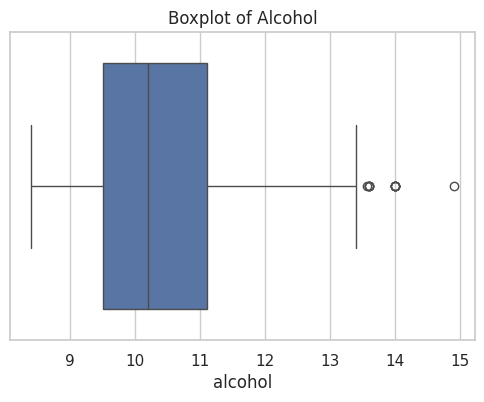

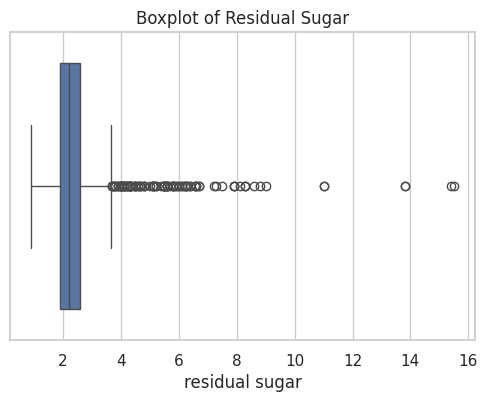

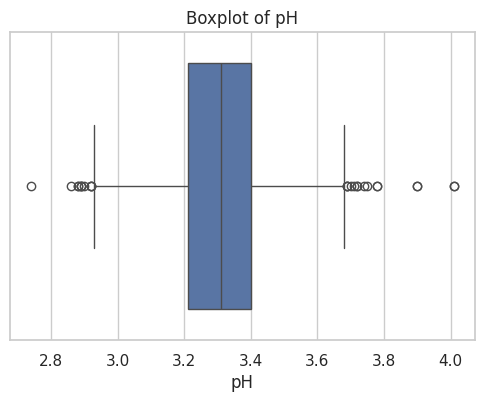

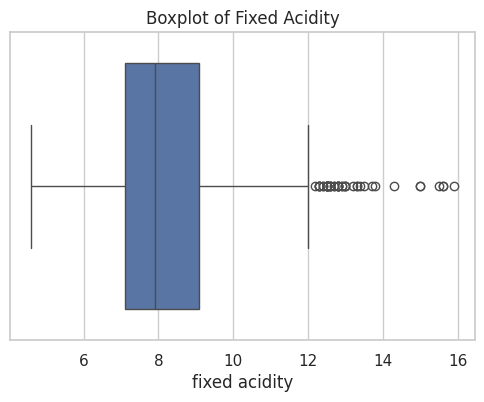

In [24]:
# Visualizing outliers for different columns in Wine dataset
plt.figure(figsize=(6,4))
sns.boxplot(x=data_remove['alcohol'])
plt.title('Boxplot of Alcohol')
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=data_remove['residual sugar'])
plt.title('Boxplot of Residual Sugar')
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=data_remove['pH'])
plt.title('Boxplot of pH')
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=data_remove['fixed acidity'])
plt.title('Boxplot of Fixed Acidity')
plt.show()

## Task 3: Detect and Handle Outliers using IQR
We use the Interquartile Range (IQR) to detect and remove outliers from the 'residual sugar' column.

In [32]:
# Task 3: Detect Outliers for 'residual sugar' (Better for showing more data)

# 1. Calculate Q1 and Q3
Q1 = df['residual sugar'].quantile(0.25)
Q3 = df['residual sugar'].quantile(0.75)

# 2. Calculate IQR
IQR = Q3 - Q1

# 3. Define boundaries
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# 4. Identify outliers
outliers = df[(df['residual sugar'] < lower) | (df['residual sugar'] > upper)]

# 5. Display the first 15 outliers (Using print to ensure it appears)
print(f"Total Outliers found: {len(outliers)}")
outliers.head(15)

# Remove outliers
df_no_outliers = df_median[(df_median['residual sugar'] >= lower_limit) & (df_median['residual sugar'] <= upper_limit)].copy()

print(f"Original shape: {df_median.shape}")
print(f"Cleaned shape: {df_no_outliers.shape}")
outliers.head(15)

Total Outliers found: 110
Original shape: (1143, 13)
Cleaned shape: (1033, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
25,7.8,0.645,0.00,5.50,0.086,5.0,18.0,0.9986,3.40,0.55,9.6,6,35
28,7.3,0.450,0.36,5.90,0.074,12.0,87.0,0.9978,3.33,0.83,10.5,5,40
45,7.2,0.725,0.05,4.65,0.086,4.0,11.0,0.9962,3.41,0.39,10.9,5,64
46,7.2,0.725,0.05,4.65,0.086,4.0,11.0,0.9962,3.41,0.39,10.9,5,65
106,7.1,0.430,0.42,5.50,0.071,28.0,128.0,0.9973,3.42,0.71,10.5,5,155
107,7.1,0.430,0.42,5.50,0.070,29.0,129.0,0.9973,3.42,0.72,10.5,5,156
108,7.1,0.430,0.42,5.50,0.071,28.0,128.0,0.9973,3.42,0.71,10.5,5,157
114,7.4,0.600,0.26,7.30,0.070,36.0,121.0,0.9982,3.37,0.49,9.4,5,163
115,7.3,0.590,0.26,7.20,0.070,35.0,121.0,0.9981,3.37,0.49,9.4,5,164
152,7.0,0.490,0.49,5.60,0.060,26.0,121.0,0.9974,3.34,0.76,10.5,5,215


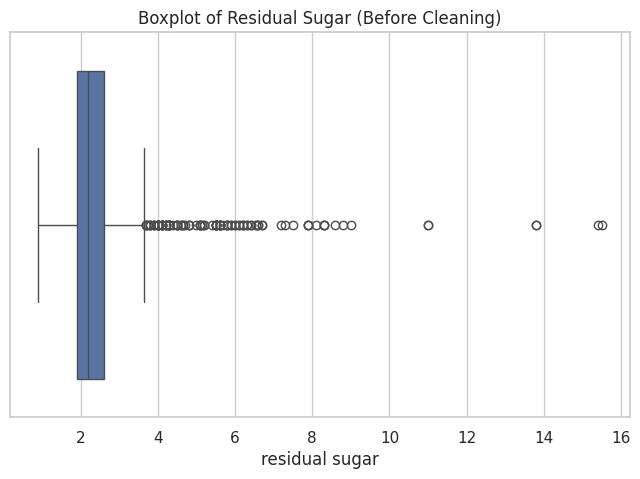

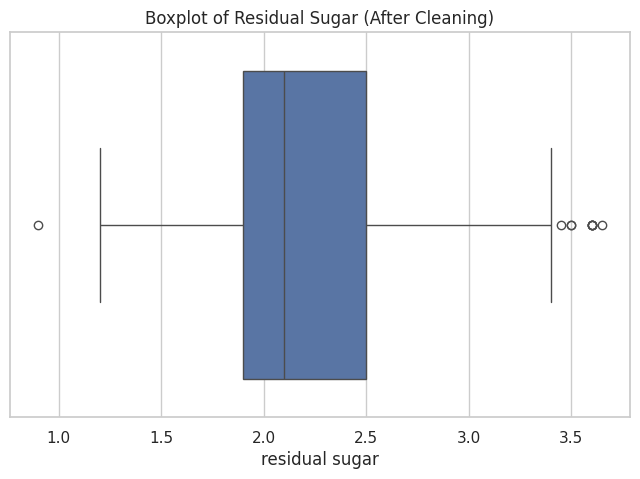

Original rows: 1143, Rows after cleaning: 1033


In [29]:
# 1. Visualize Outliers using Boxplot before cleaning
plt.figure(figsize=(8, 5))
sns.boxplot(x=df_median['residual sugar'])
plt.title('Boxplot of Residual Sugar (Before Cleaning)')
plt.show()

# 2. Calculate IQR
Q1 = df_median['residual sugar'].quantile(0.25)
Q3 = df_median['residual sugar'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR


#3. Remove Outliers
df_no_outliers = df_median[(df_median['residual sugar'] >= lower_limit) & (df_median['residual sugar'] <= upper_limit)].copy()

#4. Visualize after cleaning to confirm outliers are gone
plt.figure(figsize=(8, 5))
sns.boxplot(x=df_no_outliers['residual sugar'])
plt.title('Boxplot of Residual Sugar (After Cleaning)')
plt.show()

print(f"Original rows: {len(df_median)}, Rows after cleaning: {len(df_no_outliers)}")

## Task 4: Normalization and Scaling
We normalize numerical features using both Min-Max Scaling and Z-score (Standardization).

In [34]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()


wine_cols = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
             'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
             'pH', 'sulphates', 'alcohol', 'quality']

data_scaled = df_no_outliers[wine_cols].copy()


data_scaled[wine_cols] = scaler.fit_transform(data_scaled)


data_scaled.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,0.269231,0.397260,0.00,0.363636,0.106845,0.192308,0.176101,0.682259,0.606299,0.137725,0.321429,0.4
1,0.307692,0.520548,0.00,0.618182,0.143573,0.461538,0.383648,0.593998,0.362205,0.209581,0.321429,0.4
2,0.307692,0.438356,0.04,0.509091,0.133556,0.269231,0.301887,0.611650,0.409449,0.191617,0.321429,0.4
3,0.634615,0.109589,0.56,0.363636,0.105175,0.307692,0.339623,0.699912,0.330709,0.149701,0.321429,0.6
4,0.269231,0.397260,0.00,0.363636,0.106845,0.192308,0.176101,0.682259,0.606299,0.137725,0.321429,0.4


In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()


data_standardized = df_no_outliers[wine_cols].copy()


data_standardized[wine_cols] = scaler.fit_transform(data_standardized)


data_standardized.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,-0.511265,0.946559,-1.350134,-0.624966,-0.216063,-0.451511,-0.351968,0.685088,1.241462,-0.565003,-0.194006,-0.821948
1,-0.271148,1.947259,-1.350134,0.927200,0.236662,1.016674,0.738384,0.125286,-0.726819,0.134535,-0.194006,-0.821948
2,-0.271148,1.280126,-1.142661,0.261986,0.113191,-0.032030,0.308851,0.237247,-0.345861,-0.040349,-0.194006,-0.821948
3,1.769843,-1.388408,1.554495,-0.624966,-0.236642,0.177711,0.507097,0.797048,-0.980791,-0.448413,-0.194006,0.443436
4,-0.511265,0.946559,-1.350134,-0.624966,-0.216063,-0.451511,-0.351968,0.685088,1.241462,-0.565003,-0.194006,-0.821948


## Task 5: PCA (Dimensionality Reduction)
We apply PCA only if the numerical features show a correlation.

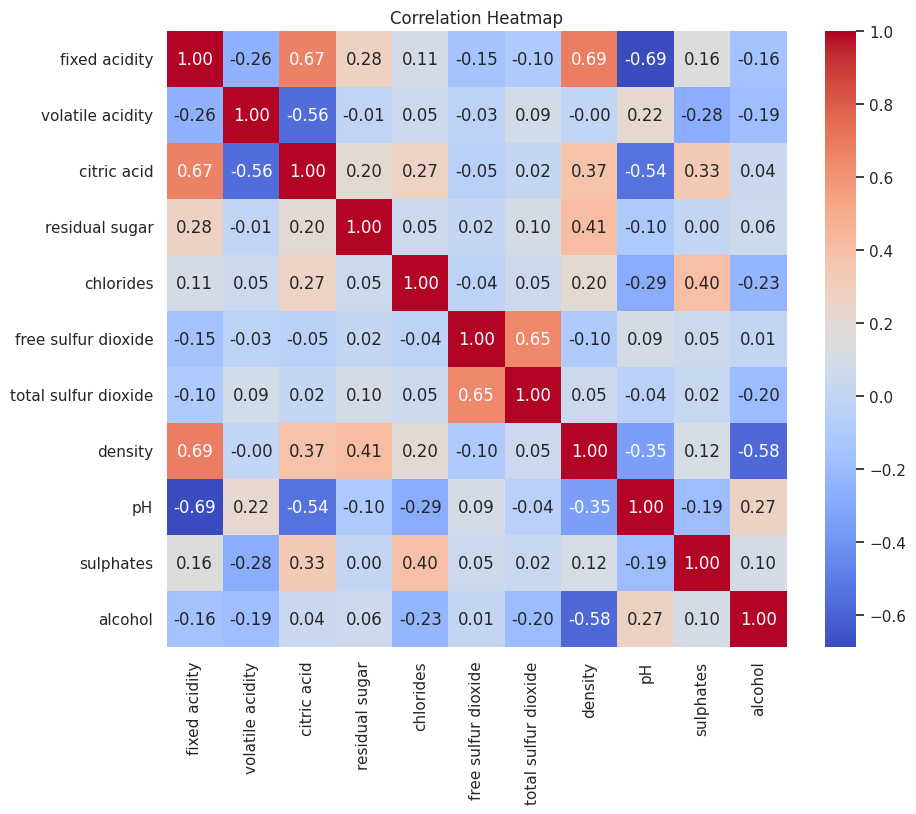

Explained Variance Ratio: [0.29356149 0.16123527]
Total information captured: 45.48%


In [19]:
# Step 1: Check Correlation
plt.figure(figsize=(10, 8))
sns.heatmap(df_no_outliers[features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# Step 2: Apply PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_std[features])

# Explained Variance
print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")
print(f"Total information captured: {sum(pca.explained_variance_ratio_)*100:.2f}%")